# Advertising Dataset — Multiple Linear Regression

A consumer goods company promotes its products through multiple advertising channels, including **Television (TV), Radio, and Newspaper**. The company has historical data containing advertising expenditure for each channel along with the corresponding product sales.

The company wants to understand **how different advertising channels influence product sales** and use this information to make better advertising budget decisions.

The objective is to build a **Multiple Linear Regression model** that learns the relationship between advertising expenditure and product sales using historical data.

The model will use:

- **TV advertising expenditure**
- **Radio advertising expenditure**
- **Newspaper advertising expenditure**

as input features and **Sales** as the target variable.

The trained model will then be used to:

- Analyze the available advertising data.
- Understand the relationship between advertising expenditure and sales.
- Train a Multiple Linear Regression model using historical data.
- Predict sales for unseen data.
- Predict sales for a planned advertising budget of **TV = 150, Radio = 20, and Newspaper = 30**.
- Evaluate the model using **MSE, RMSE, MAE, and R² Score**.
- Identify which advertising medium has the strongest and weakest estimated impact on sales.
- Visualize **Actual Sales vs Predicted Sales**.
- Provide a business recommendation for improving sales.
- Suggest a technical improvement for increasing prediction accuracy.

## Objective

The main objective is to use **Multiple Linear Regression** to determine how advertising investments across different channels affect sales and to develop a predictive model that can support **data-driven advertising and budget allocation decisions**.

In [18]:
# Import required libraries
!pip install scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\gogin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# 1. Load the dataset

In [19]:
df = pd.read_csv(r"C:\Ai_assistant\python practice\ML\Advertising.csv")

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Display columns
print("\nAvailable columns:")
print(df.columns)


First 5 rows:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Available columns:
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')


# 2. Check Dataset Information

In [20]:
# Check dataset information
print("\nDataset Information:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Duplicate Rows: 0

Statistical Summary:
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375

# 3. Separate Features and Target

In [21]:
# Separate features and target

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("X:")
print(X)

print("\ny:")
print(y)

X:
        TV  Radio  Newspaper
0    230.1   37.8       69.2
1     44.5   39.3       45.1
2     17.2   45.9       69.3
3    151.5   41.3       58.5
4    180.8   10.8       58.4
..     ...    ...        ...
195   38.2    3.7       13.8
196   94.2    4.9        8.1
197  177.0    9.3        6.4
198  283.6   42.0       66.2
199  232.1    8.6        8.7

[200 rows x 3 columns]

y:
0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64


# 4. Split the Dataset into Training and Testing Data

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 160
Testing samples: 40


# 5. Build and train the Multiple Linear Regression model

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)


# 6. Build the Multiple Linear Regression Model

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.19,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.979
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


# 7. Display the Coefficients and Intercept

In [25]:
print("Coefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

print("\nIntercept:", model.intercept_)

Coefficients:
TV: 0.0447
Radio: 0.1892
Newspaper: 0.0028

Intercept: 2.979067338122629


Therefore, the fitted equation is approximately:
\[
\boxed{
Sales = 2.9791 + 0.0447(TV) + 0.1892(Radio) + 0.0028(Newspaper)
}
\]
Interpretation of coefficients
TV coefficient = 0.0447
For every 1-unit increase in TV advertising spend, predicted sales increase by approximately 0.0447 units, assuming the other advertising channels remain constant.
Radio coefficient = 0.1892
For every 1-unit increase in Radio advertising spend, predicted sales increase by approximately 0.1892 units, assuming the other channels remain constant.
Newspaper coefficient = 0.0028
For every 1-unit increase in Newspaper advertising spend, predicted sales increase by approximately 0.0028 units, assuming the other channels remain constant.

# 8. Predict Sales for Unseen Test Data

In [26]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


# 9. Predict Sales for the Given Advertising Budget

In [27]:
# New advertising budget:
# TV = 150
# Radio = 20
# Newspaper = 30

new_budget = pd.DataFrame({
    "TV": [150],
    "Radio": [20],
    "Newspaper": [30]
})

predicted_sales = model.predict(new_budget)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 13.555229473358624


# 10. Evaluate the Model's Prediction Error

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 3. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# 4. R² Score
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Squared Error (MSE): 3.1740973539761033
Root Mean Squared Error (RMSE): 1.78159966153345
Mean Absolute Error (MAE): 1.4607567168117603
R² Score: 0.899438024100912


# 11. Identify the Strongest and Weakest
# Advertising Medium

In [29]:
print("\nAdvertising Medium Coefficients:")

# Display coefficients
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")


# Find the strongest advertising medium
strongest_medium = X.columns[np.argmax(model.coef_)]
strongest_coefficient = np.max(model.coef_)


# Find the weakest advertising medium
weakest_medium = X.columns[np.argmin(model.coef_)]
weakest_coefficient = np.min(model.coef_)


print("\nStrongest Impact:")
print(
    f"{strongest_medium} = "
    f"{strongest_coefficient:.4f}"
)

print(
    "Radio has the strongest estimated impact "
    "on Sales per unit of spend, holding the "
    "other advertising channels constant."
)


print("\nLeast Impact:")
print(
    f"{weakest_medium} = "
    f"{weakest_coefficient:.4f}"
)

print(
    "Newspaper has the least estimated impact "
    "on Sales, holding the other advertising "
    "channels constant."
)


Advertising Medium Coefficients:
TV: 0.0447
Radio: 0.1892
Newspaper: 0.0028

Strongest Impact:
Radio = 0.1892
Radio has the strongest estimated impact on Sales per unit of spend, holding the other advertising channels constant.

Least Impact:
Newspaper = 0.0028
Newspaper has the least estimated impact on Sales, holding the other advertising channels constant.


# 12. Visualize Actual Sales vs Predicted Sales

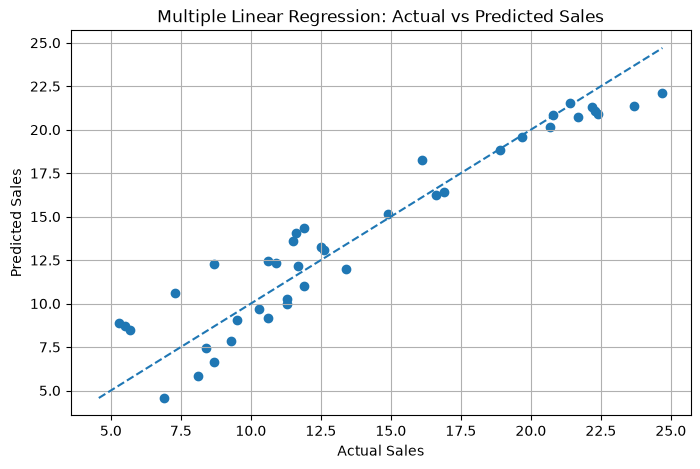

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

# Perfect prediction reference line
min_sales = min(y_test.min(), y_pred.min())
max_sales = max(y_test.max(), y_pred.max())

plt.plot(
    [min_sales, max_sales],
    [min_sales, max_sales],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Multiple Linear Regression: Actual vs Predicted Sales")

plt.grid(True)
plt.show()

# 13. Business Interpretation

In [31]:
train_pred = model.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)

Training R²: 0.8957008271017818
Testing R² : 0.899438024100912


## Strongest Advertising Medium

Based on the fitted model:

**Radio = 0.1892**

Radio has the strongest estimated coefficient among the three advertising channels.

## Least Impactful Medium

Newspaper has the smallest coefficient:

**Newspaper = 0.0028**

## Business Recommendation

**The company should consider increasing or optimizing its Radio advertising budget**, because Radio has the strongest estimated positive relationship with Sales in this model.

However, the company should not completely eliminate Newspaper advertising based only on this regression. Budget decisions should ideally also consider campaign cost, ROI, audience reach, and controlled experiments.

---

# 14. Technical Improvement

## Technical Recommendation

**Use feature engineering and more advanced models with cross-validation.**

For example, the company could:

- Add interaction features such as `TV × Radio`
- Test polynomial relationships
- Compare Linear Regression with Random Forest or Gradient Boosting
- Use k-fold cross-validation
- Tune model hyperparameters
- Analyze outliers and residuals

# Conclusion

A Multiple Linear Regression model was developed to analyze the relationship between advertising expenditure and product sales using **Television, Radio, and Newspaper** advertising data. The model was trained using historical advertising data and evaluated on unseen test data.

The model achieved an **R² score of approximately 0.8994**, indicating that it explains about **89.94% of the variation in sales** for this test split. The **MAE was approximately 1.46**, while the **RMSE was approximately 1.78**.

For the planned advertising budget of **TV = 150, Radio = 20, and Newspaper = 30**, the model predicts sales of approximately **13.56 units**.

Among the advertising channels, **Radio has the strongest estimated impact**, while **Newspaper has the weakest estimated impact** based on the fitted coefficients.

From a business perspective, the company should consider **optimizing its Radio advertising investment**, while technically, **feature engineering, cross-validation, and more advanced regression models** could be explored to improve prediction accuracy.